In [2]:
import time
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import xgboost as xgb
import lightgbm as lgb



In [3]:
# 1. Load and prepare the data
data = load_breast_cancer()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 2. Train XGBoost Model
# ==========================================
print("--- Training XGBoost ---")
xgb_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3,          # Controls level-wise depth
    random_state=42,
    eval_metric='logloss'
)

start_time = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(f"XGBoost ROC-AUC:  {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"XGBoost Time:     {xgb_time:.4f} seconds\n")


# ==========================================
# 3. Train LightGBM Model
# ==========================================
print("--- Training LightGBM ---")
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,        # Crucial for leaf-wise growth (controls complexity)
    random_state=42
)

start_time = time.time()
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - start_time

lgb_preds = lgb_model.predict(X_test)
lgb_probs = lgb_model.predict_proba(X_test)[:, 1]

print(f"LightGBM Accuracy: {accuracy_score(y_test, lgb_preds):.4f}")
print(f"LightGBM ROC-AUC:  {roc_auc_score(y_test, lgb_probs):.4f}")
print(f"LightGBM Time:     {lgb_time:.4f} seconds")

--- Training XGBoost ---
XGBoost Accuracy: 0.9561
XGBoost ROC-AUC:  0.9931
XGBoost Time:     0.0871 seconds

--- Training LightGBM ---
[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

/Users/daniel/Dev/GitHub/Repositories/machine-learning-portfolio/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/daniel/Dev/GitHub/Repositories/machine-learning-portfolio/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Decision Tree

--- Training Decision Tree ---
Accuracy: 100.00%



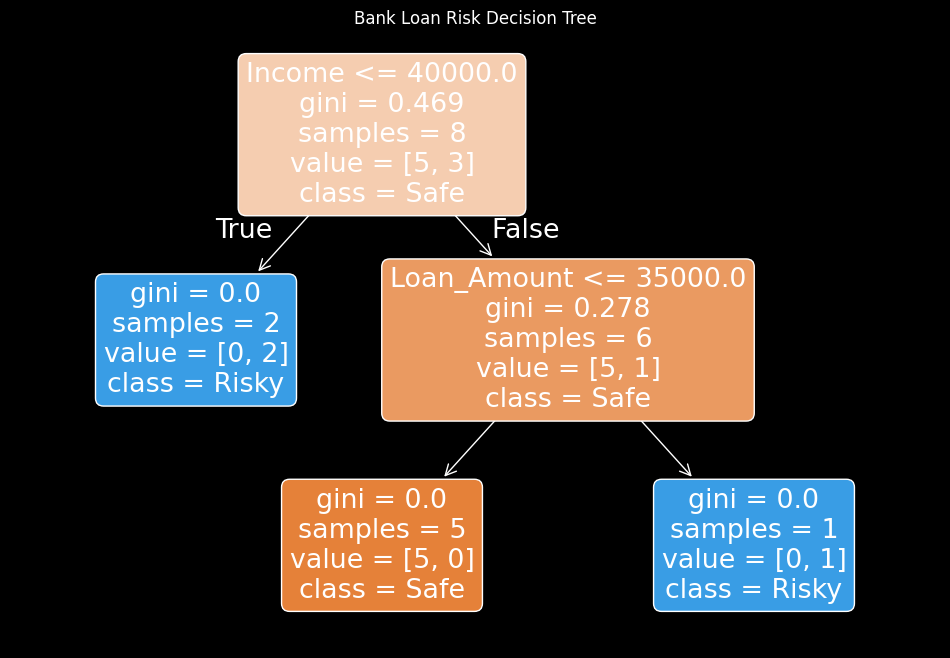

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Create a synthetic dataset
data = {
    'Credit_Score': [750, 600, 800, 620, 710, 590, 680, 740, 580, 810],
    'Income': [60000, 40000, 120000, 35000, 55000, 30000, 45000, 80000, 25000, 100000],
    'Loan_Amount': [10000, 25000, 30000, 5000, 15000, 20000, 10000, 40000, 15000, 20000],
    'Risk_Label': [0, 1, 0, 1, 0, 1, 0, 1, 1, 0] # 0 = Safe (Paid), 1 = Risky (Default)
}

df = pd.DataFrame(data)

# Define features (X) and target (y)
X = df[['Credit_Score', 'Income', 'Loan_Amount']]
y = df['Risk_Label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Train the Decision Tree
# ==========================================
print("--- Training Decision Tree ---")
# We set max_depth to prevent the tree from over-complicating (overfitting)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# Make predictions
predictions = tree_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%\n")

# ==========================================
# 3. Visualize the Tree
# ==========================================
plt.figure(figsize=(12, 8))
plot_tree(
    tree_model, 
    feature_names=['Credit_Score', 'Income', 'Loan_Amount'], 
    class_names=['Safe', 'Risky'], 
    filled=True, 
    rounded=True,
    proportion=False
)
plt.title("Bank Loan Risk Decision Tree")
plt.show()

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# 1. Create a synthetic dataset
data = {
    'Square_Feet': [1500, 2500, 1800, 3000, 1200, 2200, 2800, 1600],
    'Age_Years':   [10, 5, 20, 2, 50, 15, 8, 30],
    'Price_USD':   [250000, 400000, 220000, 500000, 150000, 350000, 450000, 180000] 
}

df = pd.DataFrame(data)

# Define features (X) and target (y)
X = df[['Square_Feet', 'Age_Years']]
y = df['Price_USD']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# ==========================================
# 2. Train the Decision Tree Regressor
# ==========================================
print("--- Training Decision Tree Regressor ---")

# max_depth controls how many splits the tree can make
regressor = DecisionTreeRegressor(max_depth=3, random_state=42)
regressor.fit(X_train, y_train)

# 3. Make predictions and evaluate
predictions = regressor.predict(X_test)

print(f"Actual Prices:    {y_test.values}")
print(f"Predicted Prices: {predictions}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, predictions):,.2f}")

--- Training Decision Tree Regressor ---
Actual Prices:    [400000 350000]
Predicted Prices: [500000. 250000.]
Mean Absolute Error: $100,000.00


In [6]:
import time
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

# 1. Load the "Larger" Dataset (20,640 houses)
california = fetch_california_housing()
X, y = california.data, california.target

# The target 'y' is expressed in hundreds of thousands of dollars ($100,000s). 
# We multiply by 100,000 to get actual dollar values for readability.
y = y * 100000 

# Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training on {len(X_train)} houses...\n")

# ==========================================
# 2. Train Random Forest
# ==========================================
print("--- Training Random Forest ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

start_time = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time

rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)

print(f"Random Forest Error (MAE): ${rf_mae:,.2f}")
print(f"Random Forest Time:        {rf_time:.2f} seconds\n")

# ==========================================
# 3. Train XGBoost
# ==========================================
print("--- Training XGBoost ---")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

start_time = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time

xgb_preds = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_preds)

print(f"XGBoost Error (MAE):       ${xgb_mae:,.2f}")
print(f"XGBoost Time:              {xgb_time:.2f} seconds")

Training on 16512 houses...

--- Training Random Forest ---
Random Forest Error (MAE): $32,761.34
Random Forest Time:        1.91 seconds

--- Training XGBoost ---
XGBoost Error (MAE):       $31,545.10
XGBoost Time:              0.17 seconds


In [7]:
import time
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. Load and split the data
california = fetch_california_housing()
X = california.data
y = california.target * 100000 # Convert to actual dollars

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Define the Parameter Grid
# ==========================================
# We are asking the grid to test 2 x 3 x 2 = 12 different model setups.
param_grid = {
    'n_estimators': [100, 200],          # Test 100 trees vs 200 trees
    'max_depth': [10, 20, None],         # Test limiting the depth vs unlimited
    'min_samples_leaf': [1, 5]           # Test requiring 1 vs 5 houses in a leaf
}

# ==========================================
# 3. Setup and Run GridSearchCV
# ==========================================
print("--- Starting Grid Search with 5-Fold Cross Validation ---")
print("Testing 12 combinations * 5 folds = 60 total training runs. Please wait...")

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# cv=5 means 5-Fold Cross-Validation!
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_absolute_error', # Optimize to reduce MAE
    verbose=1
)

start_time = time.time()
grid_search.fit(X_train, y_train)
search_time = time.time() - start_time

# ==========================================
# 4. View Results
# ==========================================
print(f"\nGrid Search Finished in {search_time:.2f} seconds.")
print(f"The Best Parameters Found: {grid_search.best_params_}")

# Extract the mathematically best model from the search
best_rf_model = grid_search.best_estimator_

# Test the best model on our completely unseen test set
final_preds = best_rf_model.predict(X_test)
final_mae = mean_absolute_error(y_test, final_preds)

print(f"Final Tuned Error (MAE): ${final_mae:,.2f}")

--- Starting Grid Search with 5-Fold Cross Validation ---
Testing 12 combinations * 5 folds = 60 total training runs. Please wait...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid Search Finished in 109.03 seconds.
The Best Parameters Found: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Final Tuned Error (MAE): $32,659.85


In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error

# 1. Load Data
california = fetch_california_housing(as_frame=True)
df = california.frame
df['Target'] = df['MedHouseVal'] * 100000

# OPTIONAL: Remove the artificial $500k cap to train a "cleaner" model
# df = df[df['Target'] < 500000]

# ==========================================
# 2. Feature Engineering
# ==========================================
print("--- Engineering New Features ---")
# Ratio Features
df['Rooms_per_Household'] = df['AveRooms'] / df['AveOccup']
df['Bedrooms_per_Room'] = df['AveBedrms'] / df['AveRooms']
df['Population_per_Household'] = df['Population'] / df['AveOccup']

# Spatial Engineering: Grouping GPS coordinates into 20 "Neighborhoods"
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df['Neighborhood_Cluster'] = kmeans.fit_predict(df[['Latitude', 'Longitude']])
# Convert cluster to category so LightGBM knows it's not a continuous number
df['Neighborhood_Cluster'] = df['Neighborhood_Cluster'].astype('category') 

# ==========================================
# 3. Train LightGBM Model
# ==========================================
X = df.drop(columns=['Target', 'MedHouseVal'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Training LightGBM ---")
# LightGBM handles the categorical 'Neighborhood_Cluster' natively
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(X_train, y_train)

# ==========================================
# 4. Evaluate
# ==========================================
preds = lgb_model.predict(X_test)
final_mae = mean_absolute_error(y_test, preds)

print(f"Engineered LightGBM Error (MAE): ${final_mae:,.2f}")

--- Engineering New Features ---
--- Training LightGBM ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2623
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 12
[LightGBM] [Info] Start training from score 207194.693738
Engineered LightGBM Error (MAE): $28,538.57


In [9]:
import time
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Load Data & Normalize Target Scale
# ==========================================
california = fetch_california_housing(as_frame=True)
df = california.frame

# We normalize the target to actual dollars for both models
df['Target'] = df['MedHouseVal'] * 100000 
y = df['Target']

# ==========================================
# 2. Reconstruct the Notebook's Approach
# ==========================================
print("--- Running Notebook's Optimized Decision Tree ---")
# The notebook uses the raw features
X_notebook = df.drop(columns=['Target', 'MedHouseVal'])
X_train_nb, X_test_nb, y_train, y_test = train_test_split(
    X_notebook, y, test_size=0.2, random_state=42
)

# Notebook's exact parameter grid (with 'auto' updated to None)
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'] 
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

start_time = time.time()
dt_grid.fit(X_train_nb, y_train)
dt_time = time.time() - start_time

dt_optimized = dt_grid.best_estimator_
dt_preds = dt_optimized.predict(X_test_nb)
dt_mae = mean_absolute_error(y_test, dt_preds)

print(f"Notebook's Decision Tree MAE: ${dt_mae:,.2f}")
print(f"Time taken: {dt_time:.2f} seconds\n")

# ==========================================
# 3. The Gradient Boosting Approach
# ==========================================
print("--- Running Engineered LightGBM ---")
# Feature Engineering step 
df_engineered = df.copy()
df_engineered['Rooms_per_Household'] = df_engineered['AveRooms'] / df_engineered['AveOccup']
df_engineered['Bedrooms_per_Room'] = df_engineered['AveBedrms'] / df_engineered['AveRooms']
df_engineered['Population_per_Household'] = df_engineered['Population'] / df_engineered['AveOccup']

kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df_engineered['Neighborhood_Cluster'] = kmeans.fit_predict(df_engineered[['Latitude', 'Longitude']])
df_engineered['Neighborhood_Cluster'] = df_engineered['Neighborhood_Cluster'].astype('category') 

X_engineered = df_engineered.drop(columns=['Target', 'MedHouseVal'])
X_train_lgb, X_test_lgb, _, _ = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42
)

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

start_time = time.time()
lgb_model.fit(X_train_lgb, y_train)
lgb_time = time.time() - start_time

lgb_preds = lgb_model.predict(X_test_lgb)
lgb_mae = mean_absolute_error(y_test, lgb_preds)

print(f"Engineered LightGBM MAE:     ${lgb_mae:,.2f}")
print(f"Time taken: {lgb_time:.2f} seconds\n")

# ==========================================
# 4. Final Comparison
# ==========================================
difference = dt_mae - lgb_mae
print("=" * 40)
print(f"LightGBM saves an average of ${difference:,.2f} in error per house!")
print("=" * 40)

--- Running Notebook's Optimized Decision Tree ---
Notebook's Decision Tree MAE: $43,105.57
Time taken: 6.50 seconds

--- Running Engineered LightGBM ---
Engineered LightGBM MAE:     $28,538.57
Time taken: 2.14 seconds

LightGBM saves an average of $14,566.99 in error per house!


In [10]:
import time
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Load Data & Normalize Target Scale
# ==========================================
california = fetch_california_housing(as_frame=True)
df = california.frame

# We normalize the target to actual dollars for both models
df['Target'] = df['MedHouseVal'] * 100000 
y = df['Target']
X = df.drop(columns=['Target', 'MedHouseVal'])

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Reconstruct the Notebook's SVR
# ==========================================
print("--- Running Notebook's SVR ---")

# The Notebook explicitly scales features for SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# The exact SVR model from the notebook
svr_model = SVR(kernel='rbf', C=1.0, gamma='scale')

start_time = time.time()
svr_model.fit(X_train_scaled, y_train)
svr_time = time.time() - start_time

svr_preds = svr_model.predict(X_test_scaled)
svr_mae = mean_absolute_error(y_test, svr_preds)

print(f"Notebook's SVR MAE: ${svr_mae:,.2f}")
print(f"Time taken:         {svr_time:.2f} seconds\n")

# ==========================================
# 3. The Engineered Gradient Boosting Approach
# ==========================================
print("--- Running Engineered LightGBM ---")

# Feature Engineering
df_eng = df.copy()
df_eng['Rooms_per_Household'] = df_eng['AveRooms'] / df_eng['AveOccup']
df_eng['Bedrooms_per_Room'] = df_eng['AveBedrms'] / df_eng['AveRooms']
df_eng['Population_per_Household'] = df_eng['Population'] / df_eng['AveOccup']

# Creating a categorical geographic feature (SVR hates these, LightGBM loves them)
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df_eng['Neighborhood_Cluster'] = kmeans.fit_predict(df_eng[['Latitude', 'Longitude']])
df_eng['Neighborhood_Cluster'] = df_eng['Neighborhood_Cluster'].astype('category') 

X_eng = df_eng.drop(columns=['Target', 'MedHouseVal'])
X_train_lgb, X_test_lgb, _, _ = train_test_split(X_eng, y, test_size=0.2, random_state=42)

# Train LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

start_time = time.time()
lgb_model.fit(X_train_lgb, y_train)
lgb_time = time.time() - start_time

lgb_preds = lgb_model.predict(X_test_lgb)
lgb_mae = mean_absolute_error(y_test, lgb_preds)

print(f"Engineered LightGBM MAE: ${lgb_mae:,.2f}")
print(f"Time taken:              {lgb_time:.2f} seconds\n")

# ==========================================
# 4. Final Comparison
# ==========================================
print("=" * 40)
print(f"LightGBM saves an average of ${(svr_mae - lgb_mae):,.2f} in error per house!")
print("=" * 40)

--- Running Notebook's SVR ---
Notebook's SVR MAE: $87,071.52
Time taken:         5.78 seconds

--- Running Engineered LightGBM ---
Engineered LightGBM MAE: $28,538.57
Time taken:              2.08 seconds

LightGBM saves an average of $58,532.95 in error per house!
